<a href="https://colab.research.google.com/github/AdrionRosanelli/LoRa_Sionna/blob/main/LoRa_SionnaPHY_Tx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Teste de Implementação do Transmissor LoRa no Sionna PHY.**

Implementação realizada a seguir:

    

# Implementação do transmissor da camada física do LoRa

*   Implementa geração de chirps
*   Modulação utilizando os chirps
*   Codifica dados em símbolos
*   Gera pacotes do LoRa

### Imports

Instalação e importação das bibliotecas. (Import do tutorial Part 1 Sionna PHY)

In [48]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import numpy as np

# For plotting
%matplotlib inline
# also try %matplotlib widget

import matplotlib.pyplot as plt

# for performance measurements
import time

In [49]:
from sionna.phy.channel import OFDMChannel, RayleighBlockFading
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, Constellation, BinarySource
from sionna.phy.utils import ebnodb2no, sim_ber
import sionna

### Implementação da camada física do LoRa no bloco.

1. Inicialização

  *   Define parâmetros do LoRa.

2. Geração de chirps do LoRa:

  *   Chirp linear variando de 0 a BW.

3. Modulação usando chirp.

4. Calculo da frequência instantânea.

5. Geração de pacotes:

  *   Preâmbulo.
  *   Sincronismo.
  *   Cabeçalho.
  *   Payload.

6. Codificação dos bits

7. Analise do chirp

In [50]:
class LoRaPhysicalLayer:
    """
    Implementação da camada física do LoRa usando Sionna
    """

    def __init__(self,
                 spreading_factor=7,      # SF7 = 128 chips por símbolo
                 bandwidth=125e3,         # 125 kHz
                 coding_rate=1,           # Taxa de codificação
                 num_preamble=8,          # Símbolos de preâmbulo
                 sync_word=0x34,          # Palavra de sincronização
                 crc_on=True,            # Habilitar CRC
                 carrier_freq=None):      # Frequência da portadora (Hz), None para desabilitar

        self.sf = spreading_factor
        self.bw = bandwidth
        self.cr = coding_rate
        self.num_preamble = num_preamble
        self.sync_word = sync_word
        self.crc_on = crc_on
        self.carrier_freq = carrier_freq

        # Parâmetros derivados
        self.n_chips = 2**self.sf  # Número de chips por símbolo
        self.symbol_duration = self.n_chips / self.bw
        self.chip_duration = 1 / self.bw

        # Polinômio CRC-16-CCITT (usado no LoRa)
        self.crc_poly = 0x1021

    def generate_chirp_sequence(self, initial_frequency=0, down_chirp=0):
        """
        Gera sequência chirp característica do LoRa
        """
        t = np.linspace(0, self.symbol_duration, self.n_chips, endpoint=False)

        # Chirp linear com frequência variando de 0 a BW
        if down_chirp==0:
          freq_slope = self.bw / self.symbol_duration
        else:
          freq_slope = -self.bw / self.symbol_duration

        chirp = np.exp(1j * 2 * np.pi * (
            initial_frequency * t + 0.5 * freq_slope * t**2))

        return chirp, t


    def modulate_symbol(self, symbol_value):
        """
        Modula um símbolo usando modulação chirp do LoRa
        """
        # Frequência inicial baseada no valor do símbolo
        freq_offset = (symbol_value * self.bw) / self.n_chips
        chirp, t = self.generate_chirp_sequence(freq_offset)

        return chirp, t

    def calculate_instantaneous_frequency(self, chirp):
        """
        Calcula a frequência instantânea do chirp usando transformada de Hilbert
        """
        analytic_signal = chirp

        # Calcular fase instantânea
        phase = np.unwrap(np.angle(analytic_signal))

        # Frequência instantânea = derivada da fase / (2*pi)
        dt = self.chip_duration
        freq_inst = np.diff(phase) / (2 * np.pi * dt)

        return freq_inst


    def generate_lora_packet(self, payload_bits):
        """
        Gera um pacote LoRa completo
        """
        packet_symbols = []
        temp_symbols = []

        # 1. Preâmbulo (chirps up)
        for _ in range(self.num_preamble):
            chirp, t = self.generate_chirp_sequence(-self.bw/2)
            packet_symbols.append(chirp)
            temp_symbols.append(t)

        # 2. Palavra de sincronização
        sync_symbols, sync_temp = self.encode_data([self.sync_word])
        for symbol in sync_symbols:
            packet_symbols.append(symbol)
        for temp in sync_temp:
            temp_symbols.append(temp)

        #gera down chirps
        dw_chirp, t = self.generate_chirp_sequence(self.bw/2, 1)
        #adiciona 2.25 down chirps
        packet_symbols.append(dw_chirp)
        packet_symbols.append(dw_chirp)
        packet_symbols.append(dw_chirp[0:len(dw_chirp)//4]) # adiciona 0.25 down
        temp_symbols.append(t)
        temp_symbols.append(t)
        temp_symbols.append(t[0:len(t)//4])

        # 3. Cabeçalho (simplificado)
        header = [len(payload_bits) // 8, self.cr, self.crc_on]
        header_symbols, header_temp = self.encode_data(header)
        for symbol in header_symbols:
            packet_symbols.append(symbol)
        for temp in header_temp:
            temp_symbols.append(temp)

        # 4. Payload
        #payload_symbols, payload_temp = self.encode_data(payload_bits)
        #for symbol in payload_symbols:
        #    packet_symbols.append(symbol)
        #for temp in payload_temp:
        #    temp_symbols.append(temp)

        # 4. Preparar payload com CRC se habilitado
        final_payload = payload_bits.copy()

        if self.crc_on:
            # Calcular CRC do payload
            crc_value = self.crc16_ccitt(payload_bits)
            crc_bits = self.crc_to_bits(crc_value)

            # Adicionar CRC ao final do payload
            final_payload.extend(crc_bits)

            print(f"CRC calculado: 0x{crc_value:04X}")
            print(f"CRC em bits: {crc_bits}")

        # 5. Codificar payload (com CRC se habilitado)
        payload_symbols, payload_temp = self.encode_data(final_payload)
        for symbol in payload_symbols:
            packet_symbols.append(symbol)
        for temp in payload_temp:
            temp_symbols.append(temp)

        # Concatenar todos os símbolos
        baseband_signal = np.concatenate(packet_symbols)
        #full_time_vector = np.concatenate(temp_symbols)
        full_time_vector = np.linspace(0, len(baseband_signal) * self.chip_duration, len(baseband_signal));

        # Aplicar modulação da portadora se habilitada
        final_signal = self.apply_carrier_modulation(baseband_signal, full_time_vector)

        return final_signal, full_time_vector

        #return np.concatenate(packet_symbols), np.concatenate(temp_symbols)

    def encode_data(self, data_bits):
        """
        Codifica dados em símbolos LoRa
        """
        symbols = []
        temp = []

        # Agrupa bits em símbolos de SF bits cada
        for i in range(0, len(data_bits), self.sf):
            symbol_bits = data_bits[i:i+self.sf]
            if len(symbol_bits) < self.sf:
                # Padding com zeros
                symbol_bits.extend([0] * (self.sf - len(symbol_bits)))

            # Converte bits para valor do símbolo
            symbol_value = sum(bit * (2**idx) for idx, bit in enumerate(symbol_bits))

            # Modula símbolo
            chirp_symbol, temp_symbol = self.modulate_symbol(symbol_value)
            symbols.append(chirp_symbol)
            temp.append(temp_symbol)

        return symbols, temp


    def crc16_ccitt(self, data):
        """
        Calcula CRC-16-CCITT para os dados
        Polinômio: x^16 + x^12 + x^5 + 1 (0x1021)
        """
        if isinstance(data[0], int) and all(isinstance(x, int) and 0 <= x <= 255 for x in data):
            # Se data é uma lista de bytes
            data_bytes = data
        else:
            # Se data é uma lista de bits, converte para bytes
            data_bytes = []
            for i in range(0, len(data), 8):
                byte_bits = data[i:i+8]
                if len(byte_bits) < 8:
                    byte_bits.extend([0] * (8 - len(byte_bits)))
                byte_val = sum(bit * (2**idx) for idx, bit in enumerate(byte_bits))
                data_bytes.append(byte_val)

        crc = 0xFFFF  # Valor inicial

        for byte in data_bytes:
            crc ^= (byte << 8)

            for _ in range(8):
                if crc & 0x8000:
                    crc = (crc << 1) ^ self.crc_poly
                else:
                    crc <<= 1
                crc &= 0xFFFF

        return crc ^ 0xFFFF  # XOR final

    def crc_to_bits(self, crc_value):
        """
        Converte valor CRC de 16 bits para lista de bits (LSB primeiro)
        """
        bits = []
        for i in range(16):
            bits.append((crc_value >> i) & 1)
        return bits

    def apply_carrier_modulation(self, baseband_signal, time_vector):
        """
        Aplica modulação da portadora ao sinal em banda base
        """
        if self.carrier_freq is None:
            return baseband_signal

        # Gera portadora complexa
        carrier = np.exp(1j * 2 * np.pi * self.carrier_freq * time_vector)

        # Modula o sinal em banda base com a portadora
        modulated_signal = baseband_signal * carrier

        return modulated_signal


    def analyze_chirp_spectrum(self):
        """
        Analisa o espectro dos chirps LoRa
        """
        # Gera diferentes chirps
        chirps = []
        for symbol_val in [0, self.n_chips//4, self.n_chips//2, 3*self.n_chips//4]:
            chirp, t = self.modulate_symbol(symbol_val)
            chirps.append(chirp)

        # Calcula espectros
        freqs = np.fft.fftfreq(self.n_chips, self.chip_duration)

        plt.figure(figsize=(12, 8))

        for i, chirp in enumerate(chirps):
            spectrum = np.fft.fft(chirp)
            plt.subplot(2, 2, i+1)
            plt.plot(freqs/1000, 20*np.log10(np.abs(spectrum)))
            plt.title(f'Espectro - Símbolo {i*(self.n_chips//4)}')
            plt.xlabel('Frequência (kHz)')
            plt.ylabel('Magnitude (dB)')
            plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

print("Classe LoRaPhysicalLayer implementada com suceso.")

Classe LoRaPhysicalLayer implementada com suceso.


### Testes e Simulação do modelo

Inicialização e configuração da LoRa PHY:

In [51]:
print("=== Simulação da Camada Física LoRa com Sionna ===\n")

# Inicializa LoRa PHY
lora_phy = LoRaPhysicalLayer(
        spreading_factor=7,
        bandwidth=125e3,
        coding_rate=1
)
print(f"Configurações LoRa:")
print(f"- Spreading Factor: {lora_phy.sf}")
print(f"- Largura de Banda: {lora_phy.bw/1000:.0f} kHz")
print(f"- Chips por símbolo: {lora_phy.n_chips}")
print(f"- Duração do símbolo: {lora_phy.symbol_duration*1000:.2f} ms")
print(f"- Taxa de símbolo: {1/lora_phy.symbol_duration:.2f} símbolos/s\n")

=== Simulação da Camada Física LoRa com Sionna ===

Configurações LoRa:
- Spreading Factor: 7
- Largura de Banda: 125 kHz
- Chips por símbolo: 128
- Duração do símbolo: 1.02 ms
- Taxa de símbolo: 976.56 símbolos/s



Análise da frequência pelo tempo:

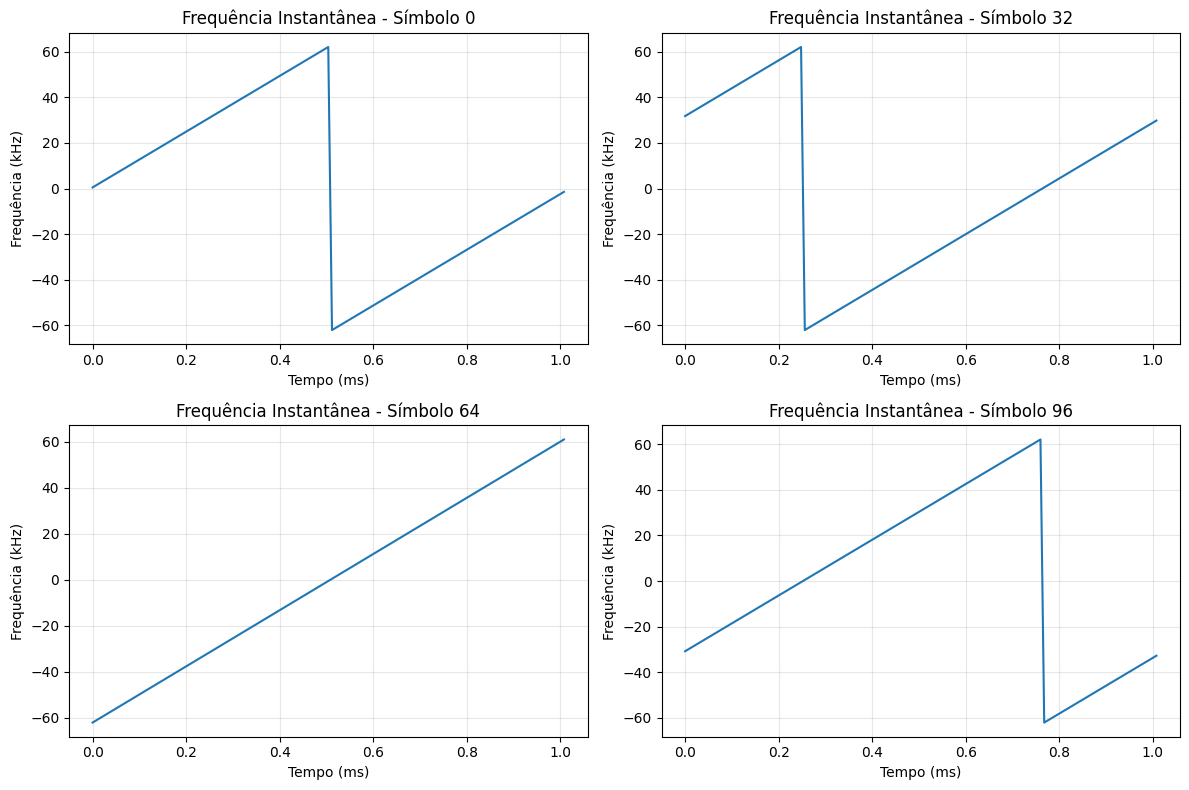

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

symbol_values = [0, 32, 64, 96]

for i, symbol_val in enumerate(symbol_values):
    chirp, t = lora_phy.modulate_symbol(symbol_val)
    freq_inst = lora_phy.calculate_instantaneous_frequency(chirp)
    t_freq = t[:-1]  # Tempo para frequência instantânea (um ponto a menos)

    # Plota parte real
    axes[i].plot(t_freq*1000, freq_inst/1000)
    axes[i].set_title(f'Frequência Instantânea - Símbolo {symbol_val}')
    axes[i].set_xlabel('Tempo (ms)')
    axes[i].set_ylabel('Frequência (kHz)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Geração de dados e pacotes:

In [53]:
# Dados para transmissão
payload = [1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1] * 4  # 64 bits
print(f"Payload: {len(payload)} bits")

# Gera pacote LoRa
packet, temp = lora_phy.generate_lora_packet(payload)
print(f"Pacote gerado: {len(packet)} amostras\n")
print(f"Duração total do pacote: {len(packet) * lora_phy.chip_duration * 1000:.2f} ms")

Payload: 64 bits
CRC calculado: 0x4CC8
CRC em bits: [0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0]
Pacote gerado: 3104 amostras

Duração total do pacote: 24.83 ms


Análise do pacote gerado

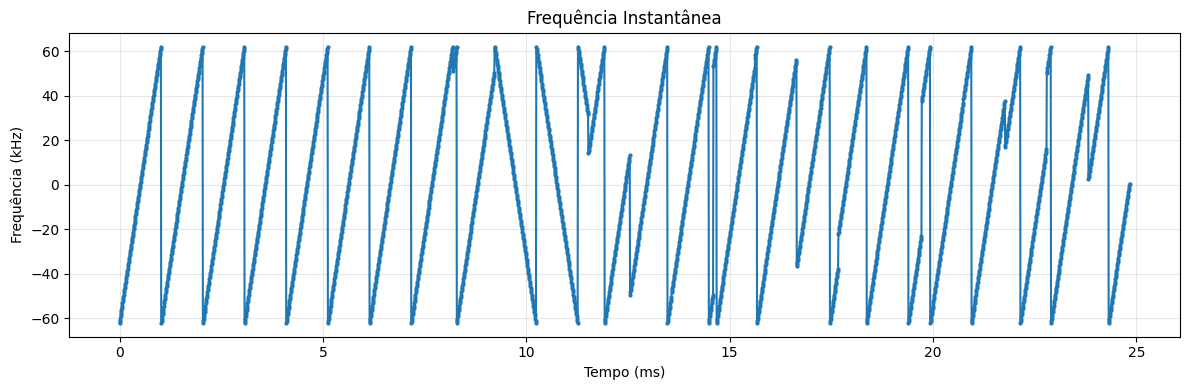

In [54]:
freq_inst = lora_phy.calculate_instantaneous_frequency(packet)
#t_freq = temp[:-1]  # Tempo para frequência instantânea (um ponto a menos)
Tempo = np.linspace(0, len(packet) * lora_phy.chip_duration, len(freq_inst));

plt.figure(figsize=(12, 4))
# Plota parte real
#plt.plot(t_freq*1000, freq_inst/1000)
plt.plot(Tempo*1000, freq_inst/1000, '-o', markersize=2)
plt.title(f'Frequência Instantânea')
plt.xlabel('Tempo (ms)')
plt.ylabel('Frequência (kHz)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Teste com utilização da portadora (em validação)

Payload: 64 bits
CRC calculado: 0x4CC8
CRC em bits: [0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0]
Pacote gerado: 3104 amostras

Duração total do pacote: 24.83 ms


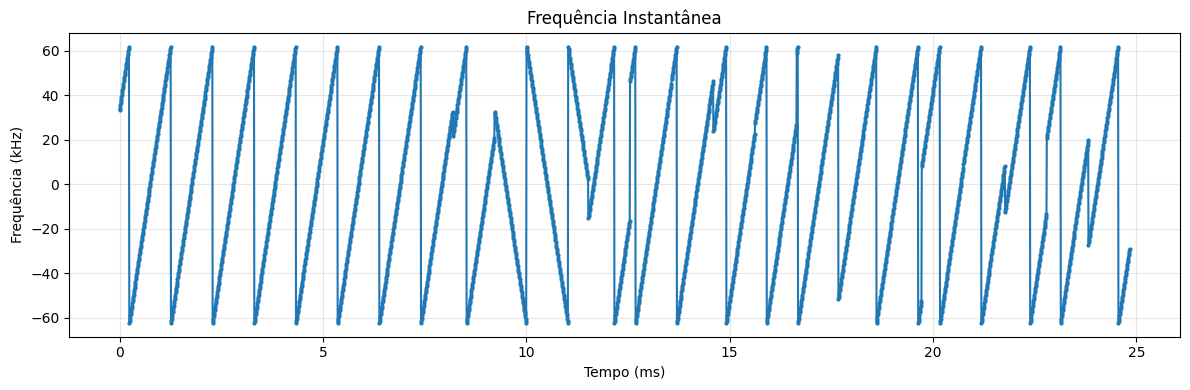

In [55]:
# Inicializa LoRa PHY
lora_phy2 = LoRaPhysicalLayer(
        spreading_factor=7,
        bandwidth=125e3,
        coding_rate=1,
        carrier_freq=916.8e6  # 916.8 MHz
)

# Dados para transmissão
payload2 = [1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1] * 4  # 64 bits
print(f"Payload: {len(payload2)} bits")

# Gera pacote LoRa
packet2, temp2 = lora_phy2.generate_lora_packet(payload2)
print(f"Pacote gerado: {len(packet2)} amostras\n")
print(f"Duração total do pacote: {len(packet2) * lora_phy2.chip_duration * 1000:.2f} ms")

freq_inst2 = lora_phy2.calculate_instantaneous_frequency(packet2)
#t_freq = temp[:-1]  # Tempo para frequência instantânea (um ponto a menos)
Tempo2 = np.linspace(0, len(packet2) * lora_phy2.chip_duration, len(freq_inst2));

plt.figure(figsize=(12, 4))
# Plota parte real
#plt.plot(t_freq*1000, freq_inst/1000)
plt.plot(Tempo2*1000, freq_inst2/1000, '-o', markersize=2)
plt.title(f'Frequência Instantânea')
plt.xlabel('Tempo (ms)')
plt.ylabel('Frequência (kHz)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Análise espectral dos chirps: (OBS: Verificar veracidade dos resultados)

Analisando espectro dos chirps...


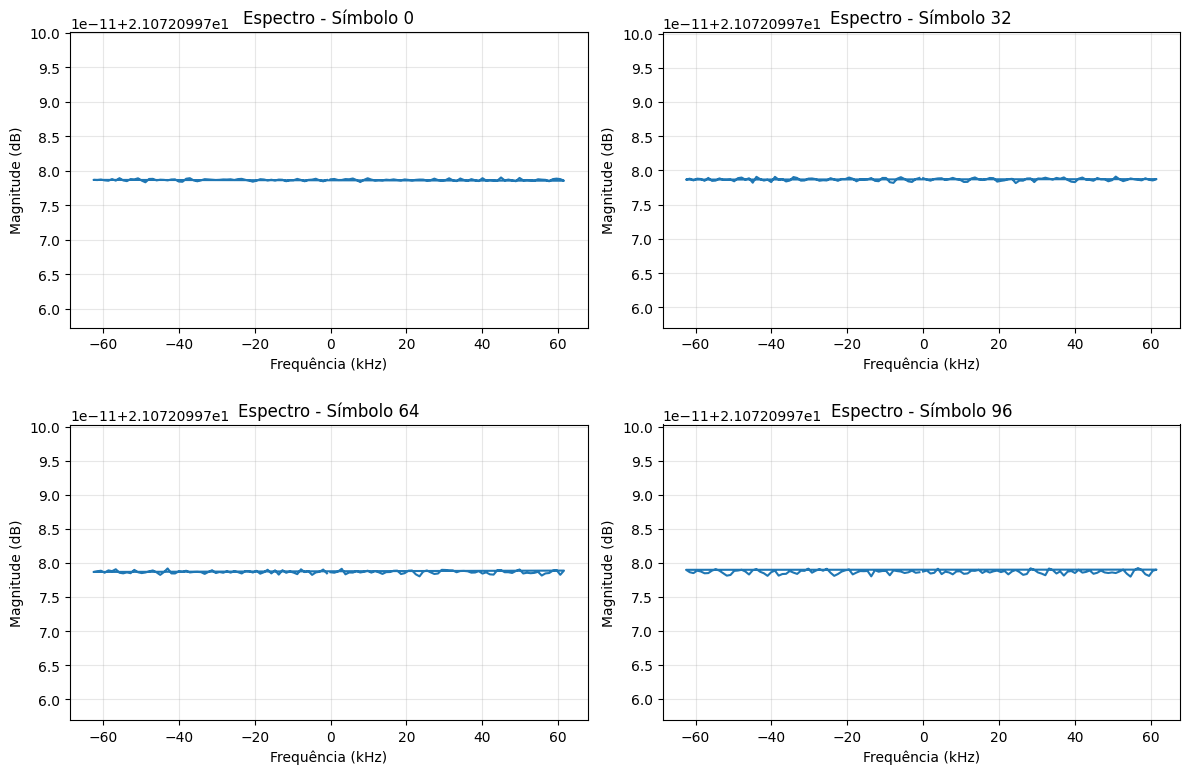

In [56]:
# Análise espectral
print("Analisando espectro dos chirps...")
lora_phy.analyze_chirp_spectrum()

Analise dos chirps no tempo:

Visualiza alguns chirps no domínio do tempo


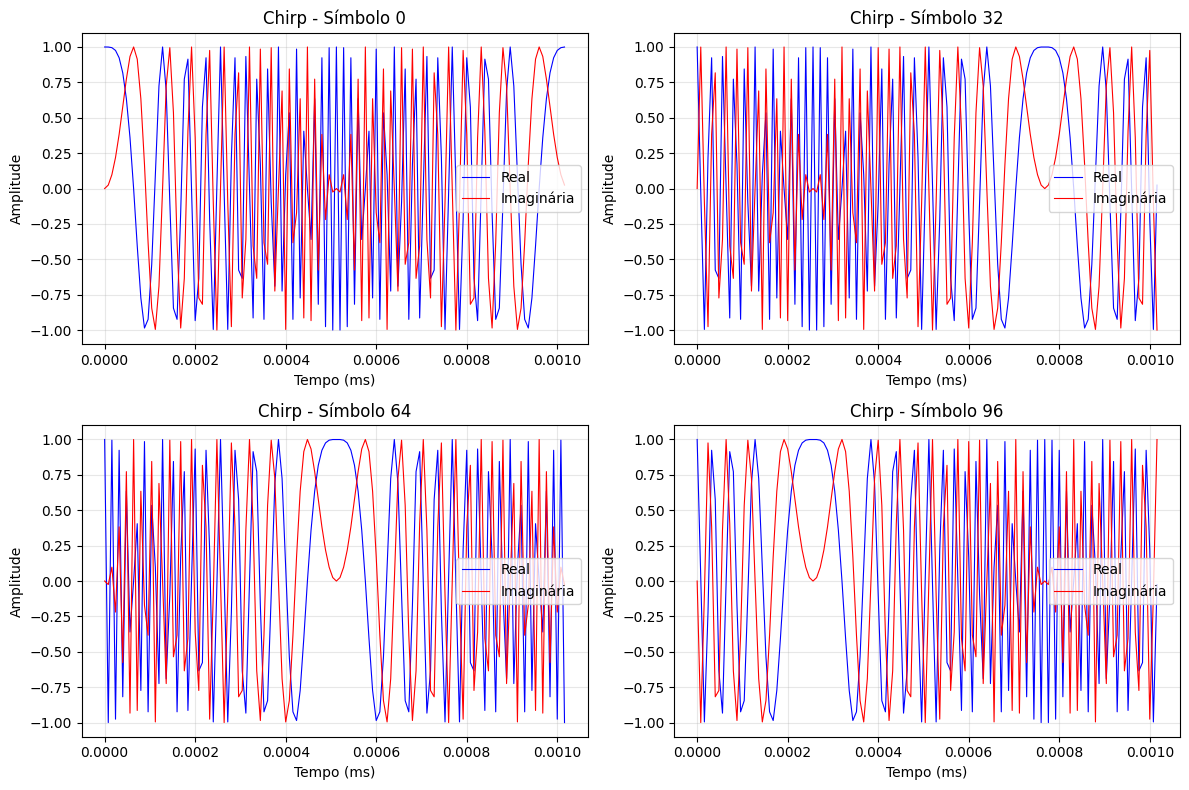

In [57]:
print("Visualiza alguns chirps no domínio do tempo")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

symbol_values = [0, 32, 64, 96]
t = np.linspace(0, lora_phy.symbol_duration*1000, lora_phy.n_chips, endpoint=False)

for i, symbol_val in enumerate(symbol_values):
    chirp, t = lora_phy.modulate_symbol(symbol_val)

    # Plota parte real
    axes[i].plot(t, np.real(chirp), 'b-', linewidth=0.8, label='Real')
    axes[i].plot(t, np.imag(chirp), 'r-', linewidth=0.8, label='Imaginária')
    axes[i].set_title(f'Chirp - Símbolo {symbol_val}')
    axes[i].set_xlabel('Tempo (ms)')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

    # Plota parte real
    #axes[i].plot(t, np.sqrt(np.real(chirp)*np.real(chirp) + np.imag(chirp)*np.imag(chirp)), 'b-', linewidth=0.8, label='Real')
    #axes[i].set_title(f'Chirp - Símbolo {symbol_val}')
    #axes[i].set_xlabel('Tempo (ms)')
    #axes[i].set_ylabel('Amplitude')
    #axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()